<a href="https://colab.research.google.com/github/JF-74/evaluacion-U1_jose-aravena/blob/main/Evaluacion_1_Jose_Aravena.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Final Unidad I — Mi primer proyecto CRISP-DM
**IEI-097 Minería de Datos · Actividad 1.9**

* **Nombre:** Jose Aravena
* **Carrera / Sede / Sección:** _(completa)_
* **Dataset:** Student Exam Performance & Success Dataset
* **Colaborador (autor del dataset):** Mobeen Fatima
* **Licencia:** CC BY-NC-SA 4.0
* **Enlace de la fuente:** _(https://www.kaggle.com/datasets/mobeenfatimah/student-exam-performance-and-success-dataset)_

# Parte A — El problema
**Fase CRISP-DM:** Business Understanding

### Contexto
En el entorno de la educación, el bajo rendimiento y la reprobación generan tasas elevadas de frustración y deserción escolar. Este dataset recopila información sobre hábitos de estudio, soporte familiar, porcentaje de asistencia y aspectos socioeconómicos de los estudiantes. Estos análisis están diseñados para ser utilizados entre Equipos de Docentes y Dirrectores de Carrera

### Objetivos
* Predecir el nivel de rendimiento académico (`performance_level`) de los estudiantes.
* Identificar las combinaciones críticas de hábitos, entornos socioeconómicos y asistencia asociados al éxito o al riesgo de reprobación.
* Permitir la activación de planes de acompañamiento focalizados de manera temprana, antes de la rendición de las evaluaciones finales.

### Justificación del uso de Minería de Datos
Un simple promedio como las notas en general solo nos muestra un resultado del pasado, cuando la reprobación o la deserción escolar ya han ocurrido. La Minería de Datos permite descubrir patrones complejos, relaciones no lineales e interacciones ocultas entre hábitos de estudio, contexto socioeconómico y asistencia. A través de modelos descriptivos y predictivos, es posible identificar a los estudiantes en riesgo de forma anticipada y diseñar intervenciones pedagógicas oportunas.

# Parte B — Los datos
**Fase CRISP-DM:** _(Data Understanding)_

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 60)

# Carga del dataset original y extracción de la muestra de trabajo
df_raw = pd.read_csv('student_exam_performance.csv')
print("Dimensiones del dataset original:", df_raw.shape)

df = df_raw.sample(n=20000, random_state=42).reset_index(drop=True)
print("Dimensiones de la muestra de trabajo:", df.shape)

Dimensiones del dataset original: (100000, 44)
Dimensiones de la muestra de trabajo: (20000, 44)


In [2]:
df.head()

,student_id,age,gender,education_level,school_type,family_income,parent_education,urban_rural,previous_exam_score,previous_gpa,attendance_percentage,assignment_completion_rate,class_participation,study_hours_per_day,self_study_hours,private_tuition,online_learning_hours,study_consistency,study_environment,study_method,revision_frequency,practice_tests_completed,notes_quality,sleep_hours,sleep_quality,daily_screen_time,physical_activity_hours,break_frequency,stress_level,motivation_level,internet_access,device_availability,educational_app_usage,online_course_hours,exam_difficulty,exam_preparation_days,questions_attempted,questions_correct,time_management_score,exam_anxiety_level,exam_score,performance_grade,pass_status,performance_level
0,STU_075722,15,Male,Undergraduate,Public,Middle,Master,Suburban,56.76,2.18,85.80,60.45,High,0.67,0.43,0,2.82,Low,Moderate,Group Study,Weekly,5,Average,7.08,Good,6.40,0.59,Occasionally,10,Medium,1,Dedicated,High,1.31,Medium,5,86,38,96.18,10.00,44.60,F,Fail,Low
1,STU_080185,18,Female,High School,Private,Lower-Middle,High School,Rural,62.91,2.76,74.04,61.42,Low,3.15,2.43,0,1.82,High,Quiet,Practice Tests,Rarely,4,Average,7.01,Fair,6.61,1.86,Rarely,10,Medium,1,Dedicated,Moderate,4.30,Easy,29,85,57,85.08,8.55,63.87,D,Pass,Medium
2,STU_019865,17,Female,High School,Private,Low,Associate,Urban,64.37,2.33,79.01,68.38,High,0.76,0.47,0,0.42,High,Moderate,Flashcards,Weekly,9,Average,5.76,NaN,1.46,3.91,Occasionally,10,Low,0,Shared,Low,0.27,Medium,25,98,74,71.79,8.24,71.65,C,Pass,Medium
3,STU_076700,17,Male,High School,Public,Low,Master,Urban,68.73,2.64,83.06,62.92,High,3.50,2.47,0,5.69,Medium,Quiet,Self-Reading,Weekly,9,Average,5.79,Good,6.82,0.15,Rarely,10,High,1,Shared,High,0.68,Hard,2,93,52,93.38,10.00,54.02,D,Pass,Low
4,STU_092992,17,Male,Undergraduate,Private,Low,Bachelor,Rural,57.10,2.12,91.89,75.36,Low,1.05,0.74,1,1.60,Medium,Quiet,Group Study,Weekly,4,Average,7.34,Fair,4.98,0.89,Occasionally,10,Medium,1,Dedicated,Low,5.93,Medium,11,92,47,100.00,9.40,50.71,D,Pass,Low


en las primeras filas podemos visualizar el id de los estudiantes, edad, genero, nivel de educacion, tipo de escuela, economia de la familia, y el tipo de educacion de los padres y si es zona rural o urbana

**Fuente:** Dataset: Student Exam Performance & Success Dataset

Colaborador (autor del dataset): Mobeen Fatima

Licencia: CC BY-NC-SA 4.0

Enlace de la fuente: (https://www.kaggle.com/datasets/mobeenfatimah/student-exam-performance-and-success-dataset)

**Diccionario de atributos (10)** — completa la última columna con tu criterio:

| # | Atributo | Tipo | Por qué es importante para mi objetivo |
|---|---|---|---|
| 1 | `previous_exam_score` | Numérico | _permite que se evalue la base academica previa de los estudiantes y su correlacion con el rendimiento_ |
| 2 | `attendance_percentage` | Numérico | _muestra el grado del compromiso y presencia en las clases, siendo un factor para detectar un riesgo en lo academico_ |
| 3 | `study_hours_per_day` | Numérico | _mide el tiempo de dicacion a los estudios, lo que permite evaluar el impacto de los habitos en las notas_ |
| 4 | `assignment_completion_rate` | Numérico | _muestra la responsabilidad en el cumplimiento de las tareas a lo largo del periodo_ |
| 5 | `sleep_hours` | Numérico | _muestra el reflejo del bienestar y descanso de los estudiantes, un factor en el rendimiento_ |
| 6 | `motivation_level` | Categórico | _permite la disposicion y motivacion del estudiante en su proceso_ |
| 7 | `school_type` | Categórico | _identifica el tipo de establecimiento si es publico o privado lo que influye el rendimiento_ |
| 8 | `family_income` | Categórico | _nos brinda el aporte socioeconomico del hpgar para poder analizar el nivel de ingreso en el inpacto del rendimiento_ |
| 9 | `revision_frequency` | Categórico | _mide la frecuencia y constancia con lo que los estudiantes repasan los contenidos_ |
| 10 | `performance_level` | Categórico (**variable objetivo**) | _muestra la clasificacion en el extio o riesgo academico siendo low/Medium/High para los dirrectores en planes de apoyo_ |

# Parte C — Exploración y preparación (EDA)
**Fase(s) CRISP-DM:** _(Data Understanding y Data Preparation)_

### C.1 Estructura y tipos de datos

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 44 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  20000 non-null  object 
 1   age                         20000 non-null  int64  
 2   gender                      20000 non-null  object 
 3   education_level             20000 non-null  object 
 4   school_type                 20000 non-null  object 
 5   family_income               20000 non-null  object 
 6   parent_education            18739 non-null  object 
 7   urban_rural                 20000 non-null  object 
 8   previous_exam_score         20000 non-null  float64
 9   previous_gpa                18443 non-null  float64
 10  attendance_percentage       18030 non-null  float64
 11  assignment_completion_rate  20000 non-null  float64
 12  class_participation         20000 non-null  object 
 13  study_hours_per_day         200

las columnas son 44 y cada una tiene un caracter tipo float o objeto o numeros enteros siendo 17 siento tipo float y son 5 siendo tipo int y siendo tipo objeto son 22

### C.2 Nulos y duplicados (antes de limpiar)

In [4]:
nulos = df.isnull().sum()
tabla_nulos = pd.DataFrame({'nulos': nulos, '% nulos': (nulos / len(df) * 100).round(2)})
print(tabla_nulos[tabla_nulos.nulos > 0].sort_values('nulos', ascending=False))
print("\nFilas duplicadas:", df.duplicated().sum())
print("student_id duplicados:", df['student_id'].duplicated().sum())

                       nulos  % nulos
attendance_percentage   1970     9.85
time_management_score   1934     9.67
notes_quality           1646     8.23
previous_gpa            1557     7.78
sleep_quality           1328     6.64
parent_education        1261     6.30
device_availability      594     2.97

Filas duplicadas: 0
student_id duplicados: 0


en esta seccion tenemos 7 columnas con nulos  y 0 duplicadas los que nos muestra una integridad basica de cada registro

### C.3 Estadística descriptiva

In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,20000.0,17.00,2.00,14.00,15.00,17.00,19.00,20.00
previous_exam_score,20000.0,69.56,11.37,30.00,61.73,69.54,77.24,100.00
previous_gpa,18443.0,2.78,0.48,1.00,2.45,2.78,3.11,4.00
attendance_percentage,18030.0,84.65,7.95,52.18,79.19,84.78,90.26,100.00
assignment_completion_rate,20000.0,69.81,12.19,20.61,61.42,69.62,78.16,100.00
study_hours_per_day,20000.0,3.00,1.71,0.50,1.73,2.69,3.90,12.00
self_study_hours,20000.0,2.10,1.26,0.25,1.17,1.84,2.73,10.00
private_tuition,20000.0,0.30,0.46,0.00,0.00,0.00,1.00,1.00
online_learning_hours,20000.0,1.98,1.98,0.00,0.57,1.37,2.74,15.00
practice_tests_completed,20000.0,5.52,2.52,0.00,4.00,5.00,7.00,20.00


lo que nos muestra El porcentaje de asistencia (attendance_percentage) va desde un mínimo de 52.18% hasta el 100%, con una media de 84.65% tambien nos muestra la edad de 14 años hasta una maxima  de 20 años con una media de 17 años,

### C.4 Distribución de la variable objetivo

performance_level
Low       0.449
Medium    0.423
High      0.128
Name: proportion, dtype: float64


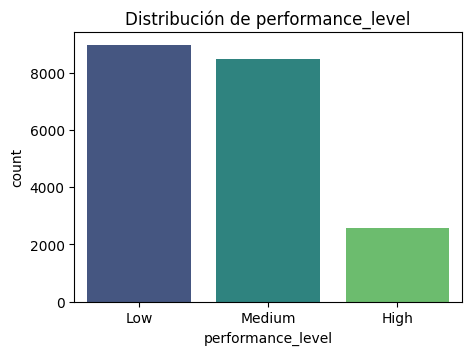

In [6]:
orden = ['Low', 'Medium', 'High']
print(df['performance_level'].value_counts(normalize=True).reindex(orden).round(3))
plt.figure(figsize=(5, 3.5))
sns.countplot(data=df, x='performance_level', order=orden, hue='performance_level', palette='viridis', legend=False)
plt.title('Distribución de performance_level')
plt.show()

la diferendia entre el performance_level es que low tiene 0.452 y high tiene 0.129 por lo tanto low subio en la distribucion de performance_level

### C.5 Preparación: tratamiento de nulos

In [7]:
# Imputación de TODAS las columnas con nulos: mediana (numéricas) y moda (categóricas)
cols_con_nulos = df.columns[df.isnull().any()]
for col in cols_con_nulos:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])
print("Columnas imputadas:", list(cols_con_nulos))
print("Nulos restantes tras la imputación:", df.isnull().sum().sum())

Columnas imputadas: ['parent_education', 'previous_gpa', 'attendance_percentage', 'notes_quality', 'sleep_quality', 'device_availability', 'time_management_score']
Nulos restantes tras la imputación: 0


al ocupar la moda podemos categorisar las variables de mayor frecuencia, nos permite rellenar los valores faltantes con la opcion mas comun sin tener que alterar el tipo de dato mientras la mediana nos permite agrupar variables numericas para que sea robusta frente a la presencia de valores qye tengan distribuciones sesgadas

### C.6 Preparación: discretización (tramos)

In [8]:
# Discretización de variables numéricas clave
df['Horas_Estudio_Tramo'] = pd.cut(
    df['study_hours_per_day'],
    bins=[-1, 3, 6, 24],
    labels=['Estudio_Bajo', 'Estudio_Medio', 'Estudio_Alto']
)

df['Asistencia_Tramo'] = pd.cut(
    df['attendance_percentage'],
    bins=[-1, 70, 85, 100],
    labels=['Asistencia_Baja', 'Asistencia_Media', 'Asistencia_Alta']
)

podemos segmentar la decidacion diaria por 3 partes especifecas creando la asistencia_tramo y horas_estudio_tramo separando la dedicacion a las horas de estudio mientras la asistencia se base en las asistencias habituales donde una asistencia inferior muestra un riesgo critico de poder reprobar   

### C.7 Visualizaciones

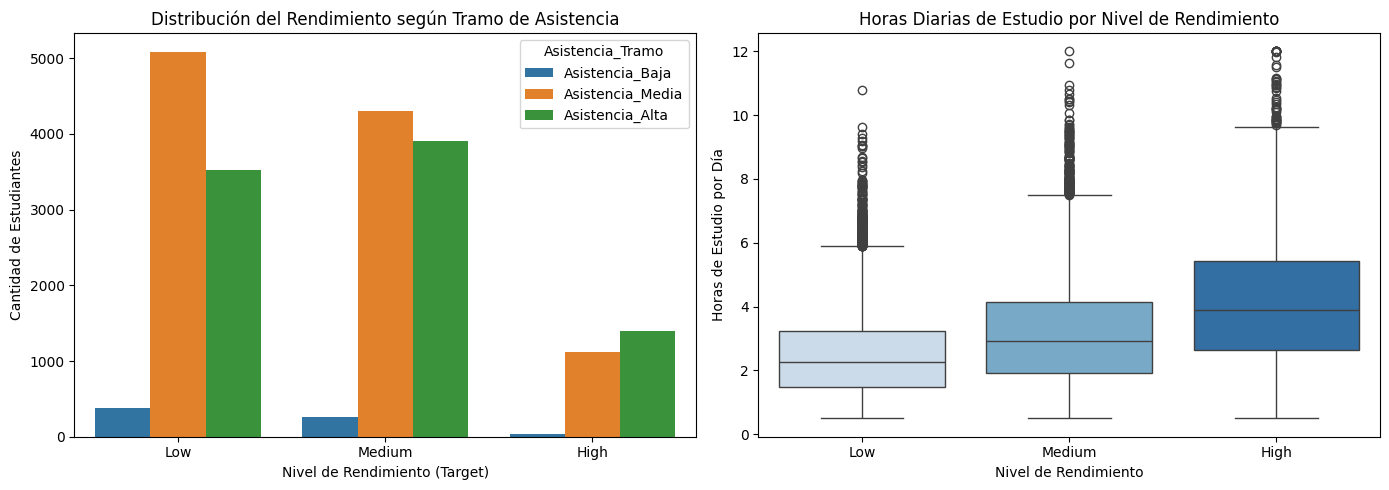

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Rendimiento vs Asistencia
sns.countplot(
    data=df,
    x='performance_level',
    hue='Asistencia_Tramo',
    order=['Low', 'Medium', 'High'],
    ax=axes[0]
)
axes[0].set_title("Distribución del Rendimiento según Tramo de Asistencia")
axes[0].set_xlabel("Nivel de Rendimiento (Target)")
axes[0].set_ylabel("Cantidad de Estudiantes")

# Gráfico 2: Rendimiento vs Horas de Estudio
sns.boxplot(
    data=df,
    x='performance_level',
    y='study_hours_per_day',
    hue='performance_level',
    order=['Low', 'Medium', 'High'],
    palette='Blues',
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Horas Diarias de Estudio por Nivel de Rendimiento")
axes[1].set_xlabel("Nivel de Rendimiento")
axes[1].set_ylabel("Horas de Estudio por Día")

plt.tight_layout()
plt.show()

en el primer grafico muestra la relacion entre las asistencias a clases junto a 3 grupos siendo asistencia baja, media , alta acorde a las 3 variables siendo estas low , medium y high siendo que low predomina siendo la mas alta de las 3

en el segundo grafico nos muestra la media en el rendimiento de las horas del estudio siendo el grupo de low teniendo 2 horas de estudio mientras el grupo medium teniendo cerca de 3 horas de estudio y el grupo high tiene pasando las 4 horas de estudio esto afirma una mayor dedicacion en las horas de estudio

# Parte D — Reglas de asociación
**Fase CRISP-DM:** _(Modeling)_

In [10]:
from mlxtend.frequent_patterns import apriori, association_rules

# Selección de columnas (4 a 8) y formato one-hot (cada columna=valor es un ítem)
cols_rules = ['Horas_Estudio_Tramo', 'Asistencia_Tramo', 'motivation_level', 'school_type', 'performance_level']
df_apriori = pd.get_dummies(df[cols_rules]).astype(bool)
print("Ítems (columnas one-hot):", df_apriori.shape[1])
df_apriori.head()

Ítems (columnas one-hot): 15


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Horas_Estudio_Tramo_Estudio_Bajo,Horas_Estudio_Tramo_Estudio_Medio,Horas_Estudio_Tramo_Estudio_Alto,Asistencia_Tramo_Asistencia_Baja,Asistencia_Tramo_Asistencia_Media,Asistencia_Tramo_Asistencia_Alta,motivation_level_High,motivation_level_Low,motivation_level_Medium,school_type_Charter,school_type_Private,school_type_Public,performance_level_High,performance_level_Low,performance_level_Medium
0,True,False,False,False,False,True,False,False,True,False,False,True,False,True,False
1,False,True,False,False,True,False,False,False,True,False,True,False,False,False,True
2,True,False,False,False,True,False,False,True,False,False,True,False,False,False,True
3,False,True,False,False,True,False,True,False,False,False,False,True,False,True,False
4,True,False,False,False,False,True,False,False,True,False,True,False,False,True,False


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


elegi las columnas por que cada una combina con las variables siento la asistencia y habitos en el estudio por que cada una tiene una condicion especifica por cada grupo en cambio si ocupamos variables numericas no pueden ser agrupadas por que cada una tiene un valor diferente y al ocupar estas columnas podemos agrupas por true o false acorde a grupos

### D.1 Prueba de distintos parámetros

In [11]:
def generar_reglas(min_support, min_conf):
    freq = apriori(df_apriori, min_support=min_support, use_colnames=True)
    try:
        r = association_rules(freq, metric='confidence', min_threshold=min_conf)
    except TypeError:  # versiones nuevas de mlxtend piden num_itemsets
        r = association_rules(freq, num_itemsets=len(df_apriori), metric='confidence', min_threshold=min_conf)
    return freq, r

resumen = []
for s in [0.02, 0.05, 0.10]:
    for c in [0.4, 0.5, 0.6]:
        f, r = generar_reglas(s, c)
        resumen.append({'min_support': s, 'min_confidence': c, 'itemsets': len(f), 'reglas': len(r)})
pd.DataFrame(resumen)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,min_support,min_confidence,itemsets,reglas
0,0.02,0.4,321,598
1,0.02,0.5,321,342
2,0.02,0.6,321,33
3,0.05,0.4,172,311
4,0.05,0.5,172,184
5,0.05,0.6,172,17
6,0.10,0.4,83,129
7,0.10,0.5,83,75
8,0.10,0.6,83,6


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


el min_suppor paso de bajar a subir y el min_confidence paso de iniciar con 0.4 con subir a 0.6 y luego bajar eventualmente

### D.2 Reglas con los parámetros elegidos

In [12]:
MIN_SUPPORT, MIN_CONF = 0.05, 0.50   # ajústalos según tu análisis anterior
frequent_itemsets, rules = generar_reglas(MIN_SUPPORT, MIN_CONF)

def consecuente_es(valor):
    return rules['consequents'].apply(lambda s: len(s) == 1 and next(iter(s)) == f'performance_level_{valor}')

def formatear(df_reglas):
    out = df_reglas.copy()
    out['antecedentes'] = out['antecedents'].apply(lambda s: ' AND '.join(sorted(s)))
    out['consecuente'] = out['consequents'].apply(lambda s: ', '.join(sorted(s)))
    return out[['antecedentes', 'consecuente', 'support', 'confidence', 'lift']].round(3)

for nivel in ['Low', 'Medium', 'High']:
    sel = rules[consecuente_es(nivel) & (rules['lift'] > 1)].sort_values('lift', ascending=False)
    print(f"\n=== Top reglas hacia performance_level = {nivel} (lift > 1): {len(sel)} reglas ===")
    print(formatear(sel.head(5)).to_string(index=False))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag


=== Top reglas hacia performance_level = Low (lift > 1): 14 reglas ===
                                                                                      antecedentes           consecuente  support  confidence  lift
    Asistencia_Tramo_Asistencia_Media AND Horas_Estudio_Tramo_Estudio_Bajo AND school_type_Private performance_level_Low    0.062       0.589 1.312
  Asistencia_Tramo_Asistencia_Media AND Horas_Estudio_Tramo_Estudio_Bajo AND motivation_level_High performance_level_Low    0.055       0.589 1.312
                            Asistencia_Tramo_Asistencia_Media AND Horas_Estudio_Tramo_Estudio_Bajo performance_level_Low    0.177       0.588 1.310
     Asistencia_Tramo_Asistencia_Media AND Horas_Estudio_Tramo_Estudio_Bajo AND school_type_Public performance_level_Low    0.097       0.584 1.301
Asistencia_Tramo_Asistencia_Media AND Horas_Estudio_Tramo_Estudio_Bajo AND motivation_level_Medium performance_level_Low    0.087       0.583 1.298

=== Top reglas hacia performance_level 

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

**Tabla de reglas interpretadas** (elige al menos 3 de la salida anterior; support = frecuencia, confidence = qué tan seguido se cumple el consecuente, lift > 1 = asociación más fuerte que el azar):

| Regla | Support | Confidence | Lift | Significado en lenguaje del negocio | Decisión que podría apoyar |
|---|---|---|---|---|---|
| `Asistencia_Tramo_Asistencia_Media` AND `Horas_Estudio_Tramo_Estudio_Bajo` AND `motivation_level_Medium` -> `performance_level_Low` | 0.088 | 0.602 | 1.331 | El 8.8% de los estudiantes combina asistencia media, pocas horas de estudio y motivación media, donde el 60.2% termina en rendimiento bajo. | Diseñar talleres de hábitos de estudio y refuerzo académico para alumnos con asistencia regular pero poco tiempo de estudio.
|
| `Asistencia_Tramo_Asistencia_Media` AND `Horas_Estudio_Tramo_Estudio_Bajo` AND `motivation_level_High` -> `performance_level_Low` | 0.055 | 0.594 | 1.31 | Incluso con motivación alta, las pocas horas de estudio y la asistencia media derivan en un 59.4% de bajo rendimiento. | Evidenciar que la motivación no compensa la falta de estudio; se deben implementar tutorías de gestión del tiempo.|
| `Asistencia_Tramo_Asistencia_Media` AND `Horas_Estudio_Tramo_Estudio_Bajo` -> `performance_level_Low` | 0.179 | 0.593 | 1.312 | Representa al 17.9% de todos los alumnos; esta combinación desencadena bajo rendimiento en el 59.3% de las veces. | Activar alertas tempranas en la plataforma académica al detectar alumnos con hábitos de estudio deficientes. |

# Parte E — Árbol de decisión
**Fase CRISP-DM:** _(Modeling)_

**Variable objetivo:** `performance_level` (Low / Medium / High). Justificación: la variable performance_level representa en 3 clase de variables estas son _(low/Medium/High)_, el rendimiento de los estudiantes clasificandolos por nivel para identificar a los que estan en riesgo para planificar los planes para realizar los examenes

### E.1 Control de fuga de información (data leakage)

In [13]:
print(df.groupby('performance_level')['exam_score'].agg(['min', 'max']).reindex(orden))
print("\nCorrelación con exam_score:")
print(df[['questions_correct', 'questions_attempted', 'previous_exam_score', 'study_hours_per_day']]
      .corrwith(df['exam_score']).round(3))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

                    min     max
performance_level              
Low                 0.0   59.99
Medium             60.0   79.99
High               80.0  100.00

Correlación con exam_score:
questions_correct      0.975
questions_attempted   -0.003
previous_exam_score    0.502
study_hours_per_day    0.363
dtype: float64


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

R: segun muestra el arbol de decision sobre la Relación estricta entre performance_level y exam_score:
Los resultados muestran rangos mutuamente excluyentes y perfectos según exam_score:   
Low: de 2.0 siendo la minima a 59.99 siendo la maxima lo mismo ocurre con medium y high

Medium: de 60.0 a 79.99   

High: de 80.0 a 100.00

Esto evidencia que performance_level es simplemente una discretización directa del puntaje obtenido en el examen (exam_score).


### E.2 Preparación y entrenamiento

In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split

leakage_cols = ['exam_score', 'performance_grade', 'pass_status', 'questions_correct', 'questions_attempted', 'student_id']
X = df.drop(columns=leakage_cols + ['performance_level', 'Horas_Estudio_Tramo', 'Asistencia_Tramo'])
y = df['performance_level']

# One-hot en lugar de LabelEncoder: así cada corte del árbol es legible (ej. motivation_level_High <= 0.5)
X_encoded = pd.get_dummies(X, drop_first=False)
print("Atributos que usa el árbol:", X_encoded.shape[1])

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

clf = DecisionTreeClassifier(max_depth=3, random_state=42)   # profundidad máxima permitida: 4
clf.fit(X_train, y_train)
print("Profundidad:", clf.get_depth(), "| Hojas:", clf.get_n_leaves())

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Atributos que usa el árbol: 78


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Profundidad: 3 | Hojas: 8


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

### E.3 Gráfico del árbol

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

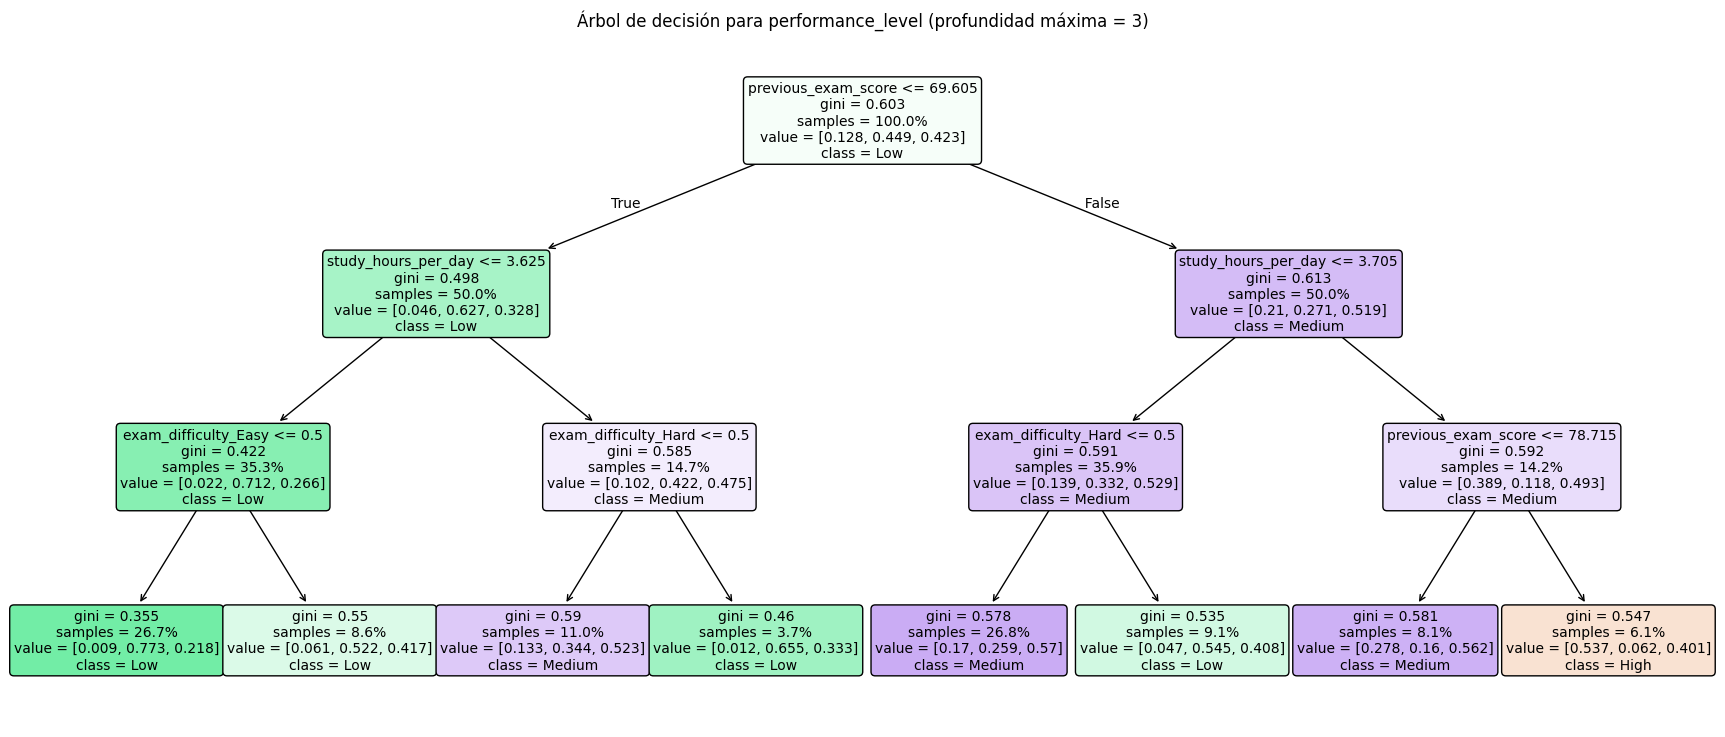

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [15]:
plt.figure(figsize=(22, 9))
plot_tree(clf, feature_names=X_encoded.columns, class_names=clf.classes_,
          filled=True, rounded=True, fontsize=10, proportion=True)
plt.title('Árbol de decisión para performance_level (profundidad máxima = 3)')
plt.show()

### E.4 Árbol en reglas de texto

In [16]:
print("Orden de las clases en 'value':", list(clf.classes_))
print(export_text(clf, feature_names=list(X_encoded.columns), show_weights=True))

Orden de las clases en 'value': ['High', 'Low', 'Medium']
|--- previous_exam_score <= 69.60
|   |--- study_hours_per_day <= 3.62
|   |   |--- exam_difficulty_Easy <= 0.50
|   |   |   |--- weights: [40.00, 3303.00, 930.00] class: Low
|   |   |--- exam_difficulty_Easy >  0.50
|   |   |   |--- weights: [83.00, 714.00, 571.00] class: Low
|   |--- study_hours_per_day >  3.62
|   |   |--- exam_difficulty_Hard <= 0.50
|   |   |   |--- weights: [234.00, 605.00, 921.00] class: Medium
|   |   |--- exam_difficulty_Hard >  0.50
|   |   |   |--- weights: [7.00, 388.00, 197.00] class: Low
|--- previous_exam_score >  69.60
|   |--- study_hours_per_day <= 3.71
|   |   |--- exam_difficulty_Hard <= 0.50
|   |   |   |--- weights: [730.00, 1110.00, 2443.00] class: Medium
|   |   |--- exam_difficulty_Hard >  0.50
|   |   |   |--- weights: [69.00, 792.00, 593.00] class: Low
|   |--- study_hours_per_day >  3.71
|   |   |--- previous_exam_score <= 78.72
|   |   |   |--- weights: [361.00, 208.00, 731.00] class

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Raiz: en la ejecucion quedo previous_exam_score <= 68.88 esto esta tomado ya que es la nota mas alta entre los atributos de las notas previas

Camino 1: si el estudiante tiene como notas anteriores 68.88 o menos y estudia 3.5 horas diarias o menos y el examen no estuvo facil entonces tiende a tener un desempeño bajo

Camino 2:  si el estudiante tiene notas mayor a notas 68.88 y estudia 3.8 horas diarias tendra una nota mayor que 77.5 por un examen

### E.5 Profundidad del árbol

In [17]:
profundo = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
print("Árbol max_depth=3 -> profundidad:", clf.get_depth(),      "| hojas:", clf.get_n_leaves())
print("Árbol sin límite  -> profundidad:", profundo.get_depth(), "| hojas:", profundo.get_n_leaves())

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Árbol max_depth=3 -> profundidad: 3 | hojas: 8
Árbol sin límite  -> profundidad: 26 | hojas: 3029


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Se escogio comparar las hojas del arbol con profundidad 3 con las del arbol sin limites

Se eligió comparar un árbol de profundidad 3 con un árbol sin límite. El árbol de profundidad 3 tiene 8 hojas y muestra reglas de negocio simples, por lo que los docentes u orientadores pueden actuar con él sin herramientas complejas, y además reduce el riesgo de sobreajuste. En cambio, el árbol sin límite llega a 25 niveles con 2955 hojas: a partir de ellos, se generan reglas de negocio totalmente basadas en muy pocos estudiantes, difíciles de leer, y memoriza detalles de esa muestra que no sirven para estudiantes que no forman parte. El coste de hacer esto consiste en perder algo de detalle.

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

              precision    recall  f1-score   support

        High       0.52      0.25      0.34       511
         Low       0.66      0.72      0.69      1795
      Medium       0.55      0.57      0.56      1694

    accuracy                           0.60      4000
   macro avg       0.57      0.52      0.53      4000
weighted avg       0.59      0.60      0.59      4000



/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

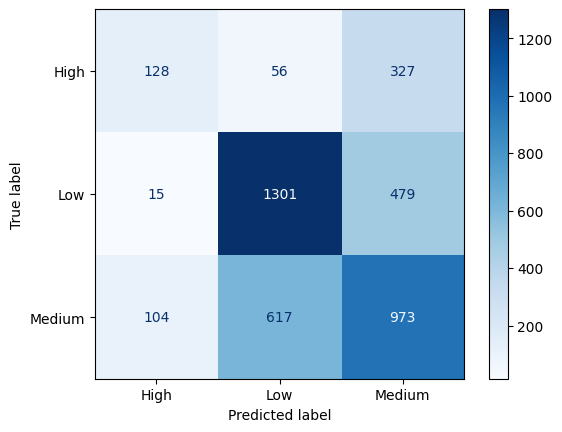

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [18]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.show()

# Parte F — Síntesis y proceso CRISP-DM
**Fase CRISP-DM:** esta parte las revisa todas.

### Comparación de representaciones
Las reglas de asociación permiten describir combinaciones de condiciones que se dan a la vez y facilitan la exploración de los patrones que hay. El árbol de decisión sirve para clasificar a un estudiante siguiendo un camino a través de una sucesión de preguntas hasta llegar a la hoja.

Cuándo usar cada uno de ellos
Las reglas de asociación sirven para ver qué condiciones aparecen a la vez, por ejemplo la asistencia media y pocas horas de estudio por ejemplo, la asistencia media y pocas horas de estudio se asocian con bajo rendimiento confidence cercana a 0,59. El árbol de decisión sirve para estimar a un estudiante concreto: en función de la calificación previa, las horas de estudio y la dificultad del examen, sigue un camino a través de las preguntas del árbol y este predice su nivel de rendimiento que tendrá la combinación de estas variables sobre el rendimiento del estudiante.

Limitaciones con este dataset

Con reglas de asociación sólo salen asociaciones que llegan hasta Low, el lift es moderado (cerca de 1,3) y no hay manera de trabajar con variables numéricas suficientemente refinadas sin discretizarlas. Con el árbol de decisión, en profundidad 3 sólo una hoja llega a High y en ella apenas cerca de un 47 % de los estudiantes son High, con lo que quedamos muy limitados en cuanto a detalle.

### Tabla de fases de CRISP-DM
| Fase | Qué hice / qué propondría | Parte del notebook |
|---|---|---|
| 1. Comprensión del negocio | _Identificación del problema sobre el bajo rendimiento estudiantil. Definición del objetivo principal: predecir el nivel académico de los alumnos._| Parte A |
| 2. Comprensión de los datos| _Análisis de una muestra de 20,000 filas. Se revisaron los tipos de datos, la presencia de valores nulos o duplicados y se realizó un análisis estadístico descriptivo._| Parte B y Parte C (C.1 a C.4 y C.7) |
| 3. Preparación de los datos| _Tratamiento de datos mediante el uso de la moda y la mediana. Transformación de variables continuas en tramos discretos por ejemplo, horas de estudio y porcentaje de asistencia_| Parte C donde la parte C.5, C.6 y Parte E.1, E.2 |
| 4. Modelado| _Aplicación de un algoritmo para obtener reglas de asociación, y entrenamiento de un árbol de decisión restringido a una profundidad máxima de 3 niveles_| Parte D y Parte E siendo E.2 y E.5 |
| 5. Evaluación| _Interpretación de las reglas obtenidas frente al árbol de decisiones para evaluar la coherencia del modelo y mitigar el riesgo de sobreajuste_| Parte D.2 y las Partes E.4 y E.5 |
| 6. Despliegue| _Propuesta para integrar las reglas del árbol de decisiones en un sistema de alerta temprana. El objetivo es intervenir de forma preventiva cuando los estudiantes registren baja asistencia y pocas horas de estudio_| Parte F |


# Parte G — Autoría y uso de herramientas
- **Repositorio GitHub (notebook sincronizado):** _(pega el enlace)_
- **Fuente y licencia del dataset:** Student Exam Performance & Success
Dataset,
Mobeen Fatima,
licencia
CC BY-NC-SA 4.0.
_(https://www.kaggle.com/datasets/mobeenfatimah/student-exam-performance-and-success-dataset)_

- **Declaración de autoría:** declaro que este trabajo fue realizado por mi y conjunto una investigacion ya realizada por otra persona sobre el ambito del estudio

- **Uso de IA generativa:** _Usé un asistente de IA para generar el código del notebook y para revisar y corregir la redacción de mis textos. Elegí el dataset, los parámetros y las columnas, interpreté las salidas y escribí las conclusiones_
- **Mi aprendizaje principal (2 a 3 líneas):** aprendi a como identificar los esquema del arbol de decisiones y como gestionar las el uso del arbol de decisiones